In [1]:
import pandas as pd 
import seaborn as sns 
import matplotlib.pyplot as plt 

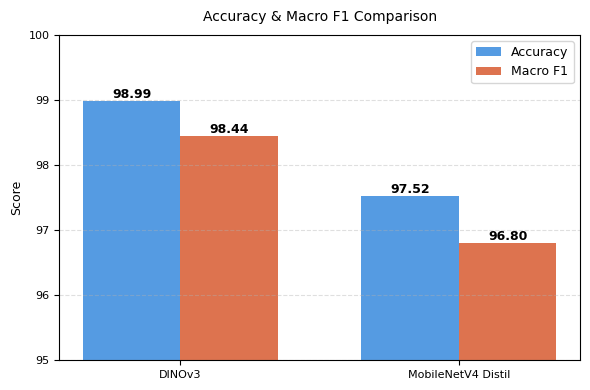

In [3]:
import matplotlib.pyplot as plt
import numpy as np

models = ["DINOv3", "MobileNetV4 Distil"]
accuracy = [98.99, 97.52]
macro_f1 = [98.44, 96.80]

x = np.arange(len(models))
width = 0.35

fig, ax = plt.subplots(figsize=(6, 4))

bars1 = ax.bar(x - width/2, accuracy, width, label='Accuracy', color='#378ADD', alpha=0.85)
bars2 = ax.bar(x + width/2, macro_f1,  width, label='Macro F1',  color='#D85A30', alpha=0.85)

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
            f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=9, weight='bold')

for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
            f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=9, weight='bold')

ax.set_ylim(95, 100)
ax.set_xticks(x)
ax.set_xticklabels(models, fontsize=9)
ax.set_ylabel("Score", fontsize=9)
ax.set_title("Accuracy & Macro F1 Comparison", fontsize=10, pad=10)
ax.tick_params(axis='both', labelsize=8)
ax.legend(fontsize=9)
ax.grid(axis='y', linestyle='--', alpha=0.4)
ax.grid(axis='x', visible=False)
plt.tight_layout()
plt.show()

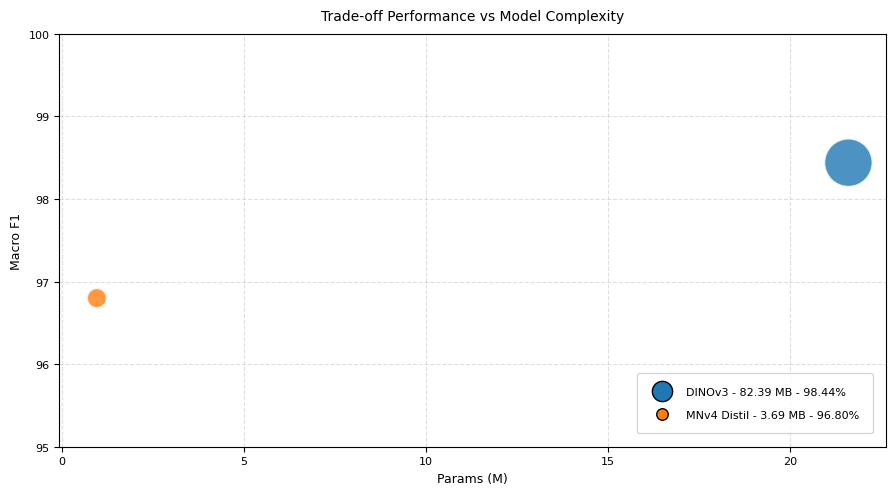

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from matplotlib.lines import Line2D

# Data
data = pd.DataFrame([
    {"model": "DINOv3",      "params_m": 21.60, "macro_f1": 98.44, "size_mb": 82.39},
    {"model": "MNv4 Distil", "params_m": 0.97,  "macro_f1": 96.80, "size_mb": 3.69},
])

plt.rcParams.update({'font.size': 8})

plt.figure(figsize=(9, 5))

# Color palette cố định để sync với legend
palette = sns.color_palette(n_colors=len(data))

# Scatter
sns.scatterplot(
    data=data,
    x="params_m",
    y="macro_f1",
    size="size_mb",
    hue="model",
    sizes=(200, 1200),
    palette=palette,
    alpha=0.8,
    # edgecolor="black",
    legend=False
)

# # Labels (dynamic offset + clamp)
# for _, row in data.iterrows():
#     label = (
#         f"{row['model']}\n"
#         f"Macro F1: {row['macro_f1']:.2f}%\n"
#         f"Size: {row['size_mb']:.2f} MB"
#     )

#     offset = 0.15 + np.sqrt(row["size_mb"]) * 0.05
#     offset = min(offset, 0.5)  # tránh quá xa

#     plt.text(
#         row["params_m"], row["macro_f1"] - offset,
#         label,
#         fontsize=8,
#         ha='left',
#         va='top'
#     )

# Custom legend
legend_elements = []
for i, row in data.iterrows():
    label = (
        f"{row['model']} - "
        f"{row['size_mb']:.2f} MB - "
        f"{row['macro_f1']:.2f}%"
    )

    legend_elements.append(
        Line2D(
            [0], [0],
            marker='o',
            color='w',
            label=label,
            markerfacecolor=palette[i],
            markeredgecolor='black',
            markersize=8 + row["size_mb"] * 0.08
        )
    )

plt.legend(
    handles=legend_elements,
    # title="Model Info",
    fontsize=8,
    title_fontsize=9,
    loc='lower right',
    frameon=True,

    labelspacing=1.2,      # 👈 giãn khoảng cách giữa các dòng
    borderpad=1.2,         # 👈 tăng padding trong box (cao hơn)
    handletextpad=1.2,     # 👈 khoảng cách giữa marker và text
    borderaxespad=1.2      # 👈 cách legend với mép plot
)

# Axes + style
plt.ylim(95, 100)
plt.title("Trade-off Performance vs Model Complexity", pad=10, fontsize=10)
plt.xlabel("Params (M)", fontsize=9)
plt.ylabel("Macro F1", fontsize=9)
plt.tick_params(axis='both', labelsize=8)
plt.grid(True, linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

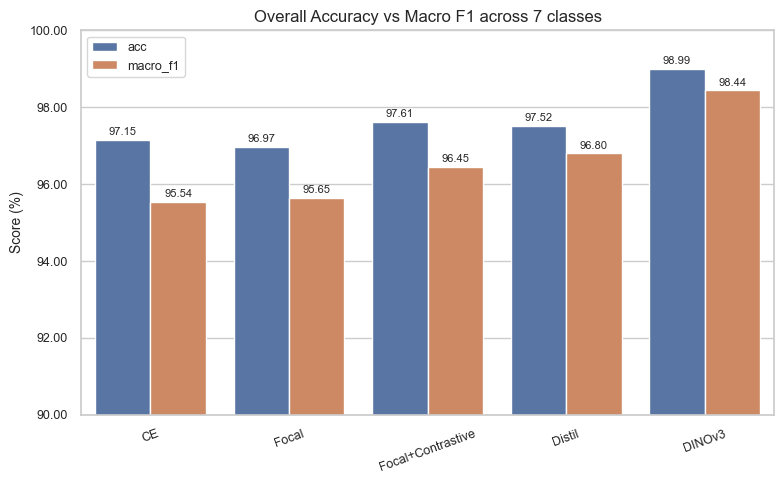

In [17]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Data
metrics = pd.DataFrame({
    "model": ["CE", "Focal", "Focal+Contrastive", "Distil", "DINOv3"],
    "acc": [0.9715, 0.9697, 0.9761, 0.9752, 0.9899],
    "macro_f1": [0.9554, 0.9565, 0.9645, 0.9680, 0.9844],
})

# Convert to %
metrics[["acc", "macro_f1"]] *= 100

# Melt
metrics_melt = metrics.melt(id_vars="model", var_name="metric", value_name="score")

# Use smaller context
sns.set_theme(style="whitegrid", context="notebook")

plt.figure(figsize=(8,5))
ax = sns.barplot(data=metrics_melt, x="model", y="score", hue="metric")

# Title (smaller)
ax.set_title("Overall Accuracy vs Macro F1 across 7 classes", fontsize=12)

# Axis labels
ax.set_xlabel("", fontsize=10)
ax.set_ylabel("Score (%)", fontsize=10)

# Tick size
ax.tick_params(axis='x', labelsize=9, rotation=20)
ax.tick_params(axis='y', labelsize=9)

# Limit
ax.set_ylim(90, 100)

# Format y-axis
ax.yaxis.set_major_formatter(lambda x, pos: f"{x:.2f}")

# Smaller legend
ax.legend(title="", fontsize=9, title_fontsize=10)

# Annotate (smaller text)
for container in ax.containers:
    ax.bar_label(container, fmt="%.2f", fontsize=8, padding=2)

plt.tight_layout()
plt.show()

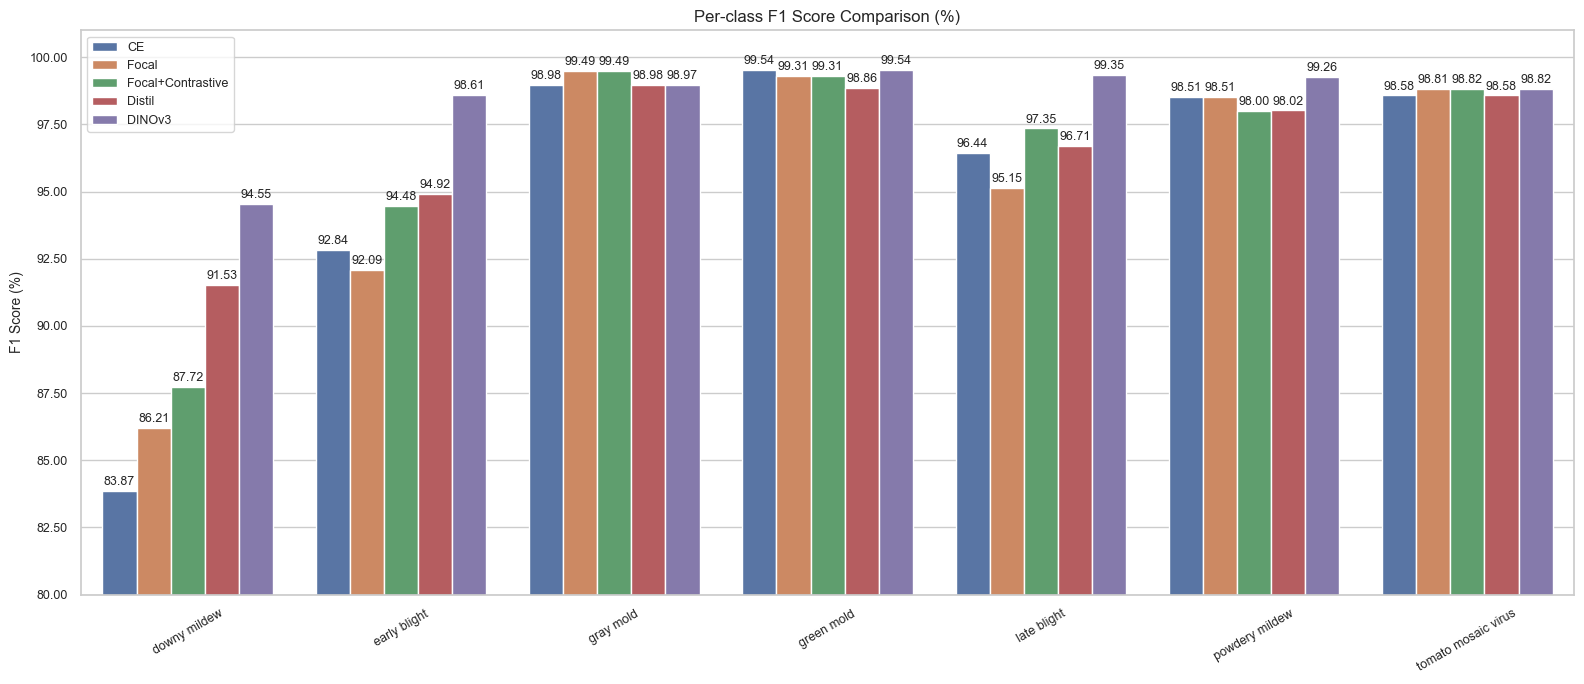

In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Classes
classes = [
    "downy mildew", "early blight", "gray mold",
    "green mold", "late blight",
    "powdery mildew", "tomato mosaic virus"
]

# Real F1 values (per class)
f1_data = pd.DataFrame({
    "class": classes,
    "CE": [0.8387, 0.9284, 0.9898, 0.9954, 0.9644, 0.9851, 0.9858],
    "Focal": [0.8621, 0.9209, 0.9949, 0.9931, 0.9515, 0.9851, 0.9881],
    "Focal+Contrastive": [0.8772, 0.9448, 0.9949, 0.9931, 0.9735, 0.9800, 0.9882],
    "Distil": [0.9153, 0.9492, 0.9898, 0.9886, 0.9671, 0.9802, 0.9858],
    "DINOv3": [0.9455, 0.9861, 0.9897, 0.9954, 0.9935, 0.9926, 0.9882],
})

# Convert to percentage
f1_data.iloc[:, 1:] *= 100

# Melt
f1_melt = f1_data.melt(id_vars="class", var_name="model", value_name="f1")

# Style
sns.set_theme(style="whitegrid", context="notebook")

plt.figure(figsize=(16,7))
ax = sns.barplot(data=f1_melt, x="class", y="f1", hue="model")

# Title & labels
ax.set_title("Per-class F1 Score Comparison (%)", fontsize=12)
ax.set_xlabel("", fontsize=10)
ax.set_ylabel("F1 Score (%)", fontsize=10)

# Axis formatting
ax.set_ylim(80, 101)
ax.tick_params(axis='x', labelsize=9, rotation=30)
ax.tick_params(axis='y', labelsize=9)
ax.yaxis.set_major_formatter(lambda x, pos: f"{x:.2f}")

# Legend (smaller)
ax.legend(title="", fontsize=9)

# Annotate bars
for container in ax.containers:
    ax.bar_label(container, fmt="%.2f", fontsize=9, padding=2)

plt.tight_layout()
plt.show()

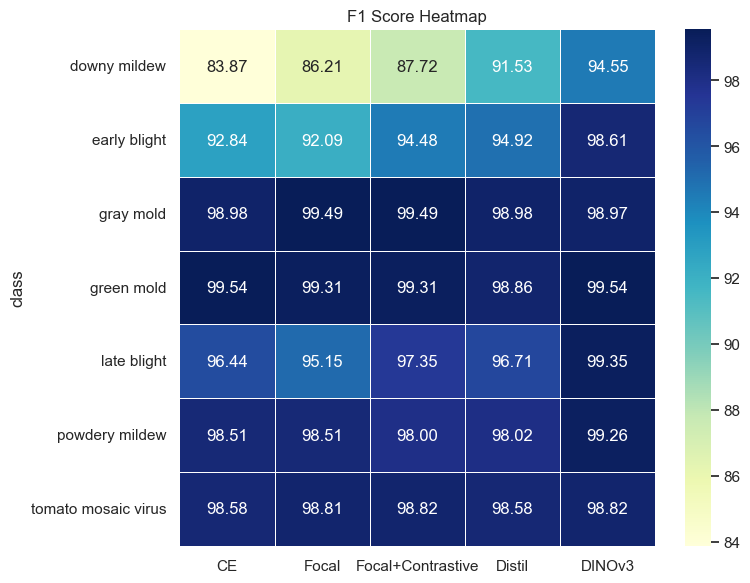

In [4]:
heatmap_data = f1_data.set_index("class")

plt.figure(figsize=(8,6))
sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".2f",
    cmap="YlGnBu",
    linewidths=0.5
)

plt.title("F1 Score Heatmap")
plt.tight_layout()
plt.show()

storytelling

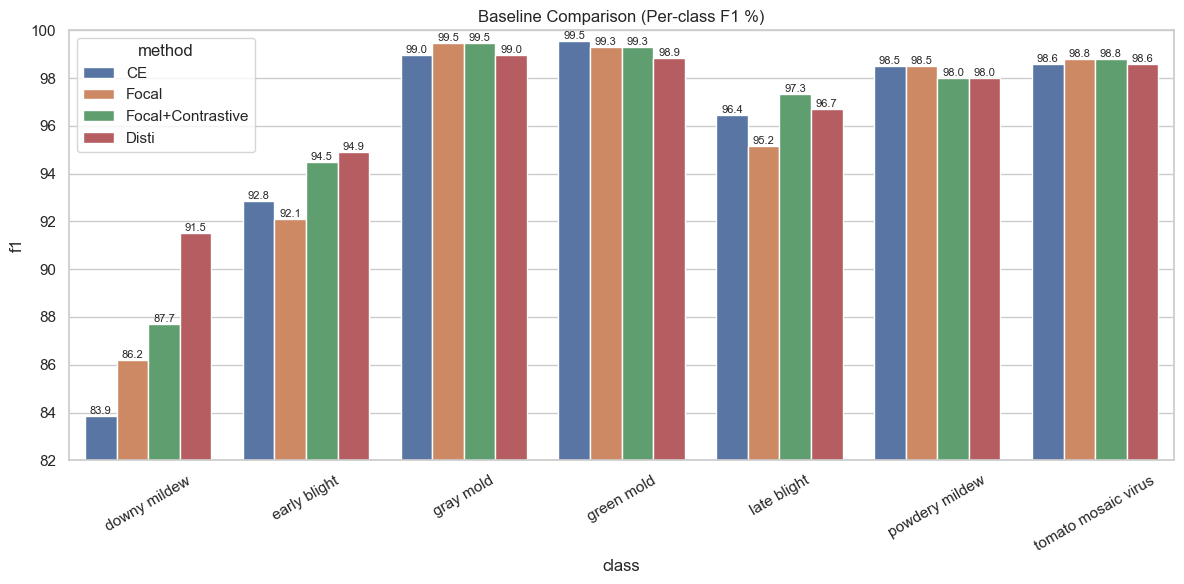

In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Data (%)
classes = [
    "downy mildew", "early blight", "gray mold",
    "green mold", "late blight",
    "powdery mildew", "tomato mosaic virus"
]

df = pd.DataFrame({
    "class": classes,
    "CE": [83.87, 92.84, 98.98, 99.54, 96.44, 98.51, 98.58],
    "Focal": [86.21, 92.09, 99.49, 99.31, 95.15, 98.51, 98.81],
    "Focal+Contrastive": [87.72, 94.48, 99.49, 99.31, 97.35, 98.00, 98.82],
    "Disti": [91.53, 94.92, 98.98, 98.86, 96.71, 98.02, 98.58],
})

melt = df.melt(id_vars="class", var_name="method", value_name="f1")

sns.set_theme(style="whitegrid")
plt.figure(figsize=(12,6))

ax = sns.barplot(data=melt, x="class", y="f1", hue="method")

ax.set_title("Baseline Comparison (Per-class F1 %)")
ax.set_ylim(82, 100)
ax.tick_params(axis='x', rotation=30)

for c in ax.containers:
    ax.bar_label(c, fmt="%.1f", fontsize=8)

plt.tight_layout()
plt.show()

                 class  Distil - CE  Distil - Focal  Distil - Contrastive
0         downy mildew         7.66            5.32                  3.81
1         early blight         2.08            2.83                  0.44
2            gray mold         0.00           -0.51                 -0.51
3           green mold        -0.68           -0.45                 -0.45
4          late blight         0.27            1.56                 -0.64
5       powdery mildew        -0.49           -0.49                  0.02
6  tomato mosaic virus         0.00           -0.23                 -0.24


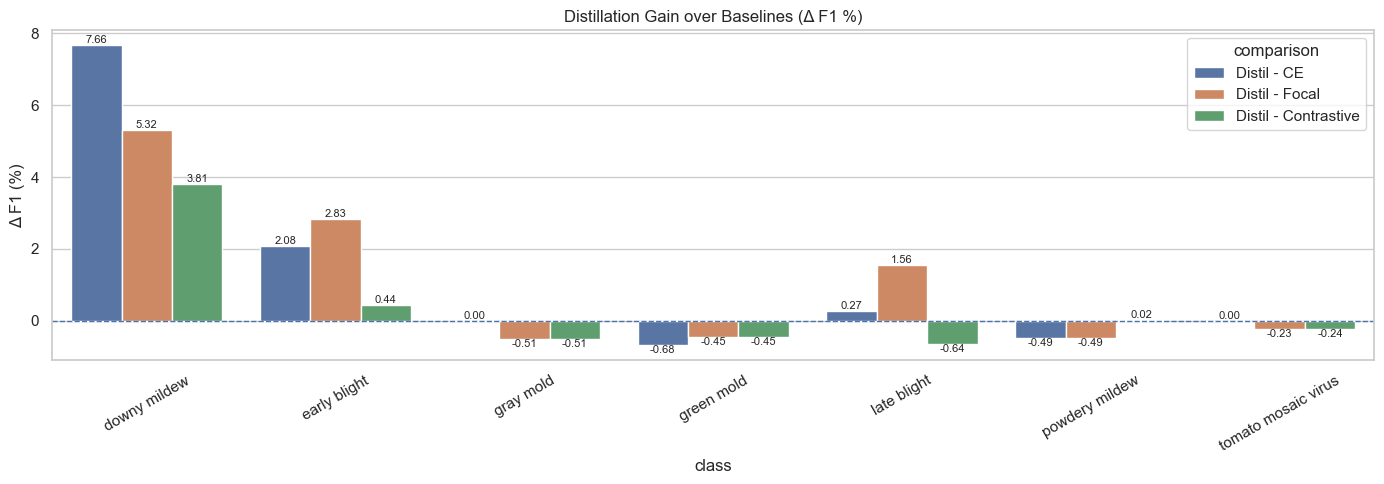

In [4]:
# Add Distil
df["Distil"] = [91.53, 94.92, 98.98, 98.86, 96.71, 98.02, 98.58]

delta = pd.DataFrame({
    "class": classes,
    "Distil - CE": df["Distil"] - df["CE"],
    "Distil - Focal": df["Distil"] - df["Focal"],
    "Distil - Contrastive": df["Distil"] - df["Focal+Contrastive"],
})

print(delta)

delta_melt = delta.melt(id_vars="class", var_name="comparison", value_name="delta")

plt.figure(figsize=(14,5))

ax = sns.barplot(data=delta_melt, x="class", y="delta", hue="comparison")

plt.axhline(0, linestyle="--", linewidth=1)

ax.set_title("Distillation Gain over Baselines (Δ F1 %)")
ax.set_ylabel("Δ F1 (%)")
ax.tick_params(axis='x', rotation=30)

for c in ax.containers:
    ax.bar_label(c, fmt="%.2f", fontsize=8)

plt.tight_layout()
plt.show()

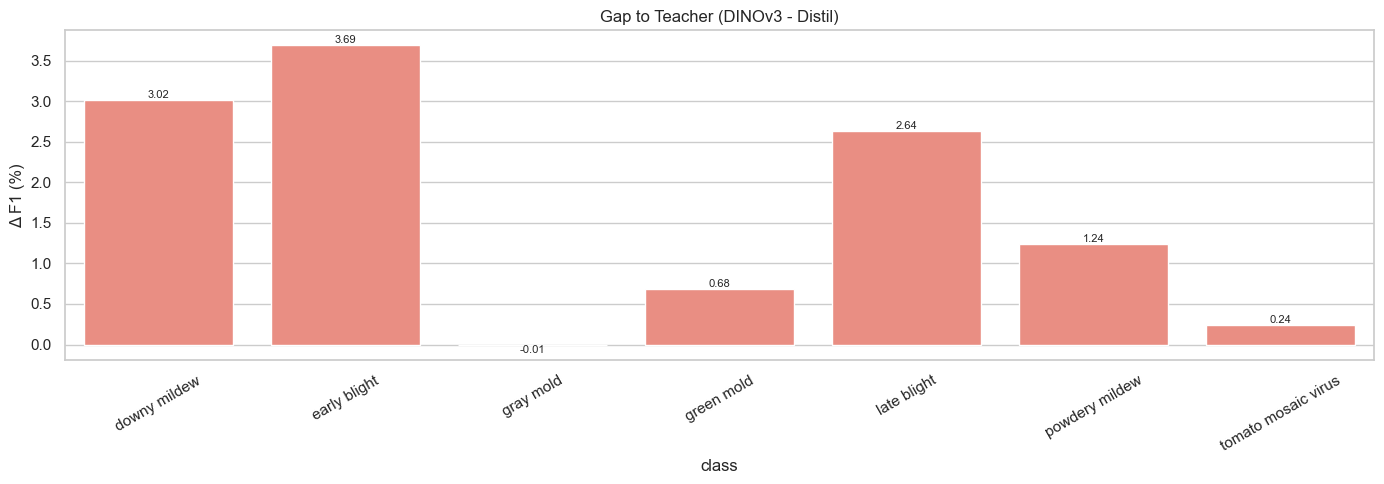

In [44]:
# Add DINOv3
df["DINOv3"] = [94.55, 98.61, 98.97, 99.54, 99.35, 99.26, 98.82]

gap = pd.DataFrame({
    "class": classes,
    "Teacher Gap": df["DINOv3"] - df["Distil"]
})

plt.figure(figsize=(14,5))

ax = sns.barplot(data=gap, x="class", y="Teacher Gap", color="salmon")

ax.set_title("Gap to Teacher (DINOv3 - Distil)")
ax.set_ylabel("Δ F1 (%)")
ax.tick_params(axis='x', rotation=30)

for c in ax.containers:
    ax.bar_label(c, fmt="%.2f", fontsize=8)

plt.tight_layout()
plt.show()

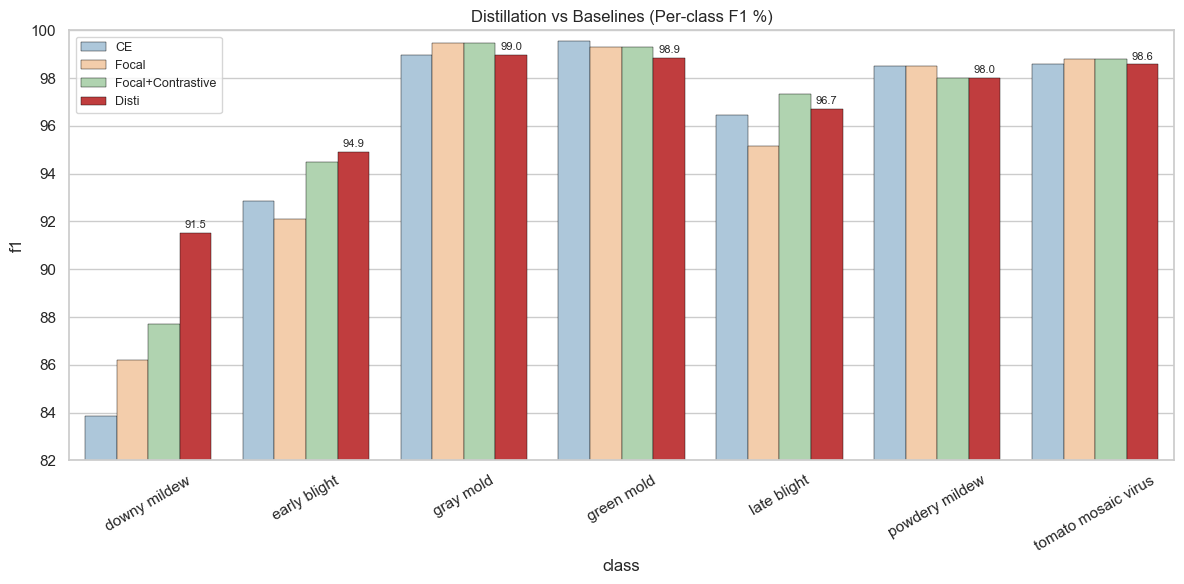

In [48]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.colors as mc

# ===== Data =====
classes = [
    "downy mildew", "early blight", "gray mold",
    "green mold", "late blight",
    "powdery mildew", "tomato mosaic virus"
]

df = pd.DataFrame({
    "class": classes,
    "CE": [83.87, 92.84, 98.98, 99.54, 96.44, 98.51, 98.58],
    "Focal": [86.21, 92.09, 99.49, 99.31, 95.15, 98.51, 98.81],
    "Focal+Contrastive": [87.72, 94.48, 99.49, 99.31, 97.35, 98.00, 98.82],
    "Disti": [91.53, 94.92, 98.98, 98.86, 96.71, 98.02, 98.58],
})

melt = df.melt(id_vars="class", var_name="method", value_name="f1")

# ===== Helper: làm nhạt màu (blend với trắng) =====
def lighten_color(color, amount=0.6):
    c = mc.to_rgb(color)
    return tuple(1 - (1 - x) * (1 - amount) for x in c)

# ===== Base palette =====
base_colors = sns.color_palette("tab10", 4)

palette = {
    "CE": lighten_color(base_colors[0], 0.6),
    "Focal": lighten_color(base_colors[1], 0.6),
    "Focal+Contrastive": lighten_color(base_colors[2], 0.6),
    "Disti": base_colors[3],  # 👈 giữ đậm để highlight
}

# ===== Plot =====
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12,6))

ax = sns.barplot(
    data=melt,
    x="class",
    y="f1",
    hue="method",
    palette=palette
)

# Title & axis
ax.set_title("Distillation vs Baselines (Per-class F1 %)", fontsize=12)
ax.set_ylim(82, 100)
ax.tick_params(axis='x', rotation=30)

# Viền mỏng cho đẹp (paper style)
for p in ax.patches:
    p.set_edgecolor('black')
    p.set_linewidth(0.3)

# Annotate: chỉ hiện Distil để tránh rối
methods = ["CE", "Focal", "Focal+Contrastive", "Disti"]
for container, method in zip(ax.containers, methods):
    if method == "Disti":
        ax.bar_label(container, fmt="%.1f", fontsize=8, padding=2)

# Legend
ax.legend(title="", fontsize=9)

plt.tight_layout()
plt.show()